In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
Pa_In = Path(r'../../../data/KNMI23/pet') # Let's just load PET for now.

In [5]:
l_NC_Fi = [f for f in Pa_In.iterdir() if f.is_file() and f.suffix == '.nc']

In [6]:
# Load and Explore .nc Files
for f in l_NC_Fi[:1]:
    Pa_Fi = Pa_In / f
    print(f'\n### Loading File: {f} ###\n')
    
    # Load with xarray
    DS = xr.open_dataset(Pa_Fi)
    print(DS)  # Prints file structure and variables
    
    # Explore global attributes (metadata)
    print('\n--- Global Attributes (Metadata) ---')
    for attr in DS.attrs:
        print(f'{attr}: {DS.attrs[attr]}')
    
    # List variables and their dimensions
    print('\n--- Variables and Dimensions ---')
    for var in DS.data_vars:
        print(f'{var}: {DS[var].dims}')
    
    # Optional: Load a specific variable and print its metadata
    example_var = list(DS.data_vars.keys())[0]  # Get first variable
    print(f'\n--- Example Variable "{example_var}" ---')
    print(DS[example_var])
    
    # Close the dataset to free memory
    DS.close()


### Loading File: ..\..\..\data\KNMI23\pet\pet_Hd_2050_interp.nc ###

<xarray.Dataset> Size: 415MB
Dimensions:  (lat: 32, lon: 37, time: 10957, ens: 8)
Coordinates:
  * lat      (lat) float64 256B 50.6 50.7 50.8 50.9 51.0 ... 53.4 53.5 53.6 53.7
  * lon      (lon) float64 296B 2.9 3.025 3.15 3.275 ... 7.025 7.15 7.275 7.4
  * time     (time) datetime64[ns] 88kB 2036-01-01 2036-01-02 ... 2065-12-30
  * ens      (ens) int32 32B 1 2 3 4 5 6 7 8
Data variables:
    mask     (lat, lon) int32 5kB ...
    pet      (time, ens, lat, lon) float32 415MB ...
Attributes:
    title:        KNMI'23 scenario's
    institution:  KNMI
    description:  Final data used to create the KNMI'23 scenario tables.\nPro...
    references:   'KNMI National Climate Scenarios 2023 for the Netherlands',...
    comment:      Due to the re-gridding, numbers obtained from this dataset ...
    created:      08.12.2023 14:41:52 by Andreas Sterl
    version:      V2. Superseeds files with creation date before 28 Nov 2023

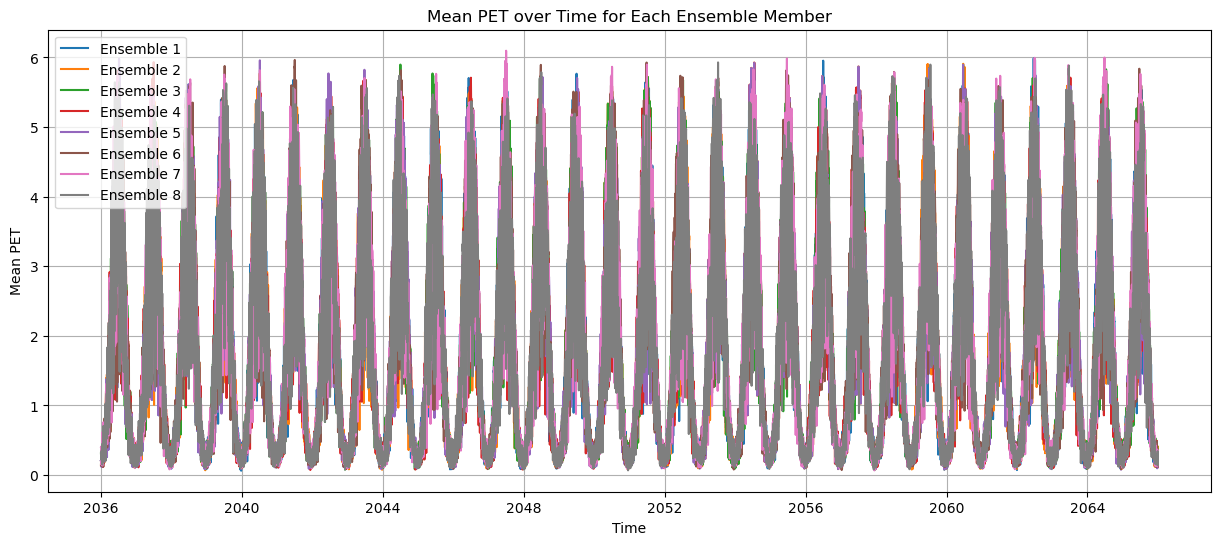

In [7]:
# Calculate the spatial mean for each ensemble over the grid
DS_mean = DS['pet'].mean(dim=['lat', 'lon'])  # Adjust grid dimensions as needed

DS_mean = DS_mean.sel()

# Plot time vs. mean values for each ensemble member
plt.figure(figsize=(15, 6))

for ens_member in DS_mean['ens'].values:  # Loop over all ensemble members
    DS_mean_ens = DS_mean.sel(ens=ens_member)  # Select the ensemble member
    plt.plot(DS_mean_ens['time'], DS_mean_ens, label=f"Ensemble {ens_member}")

# Add plot details
plt.title("Mean PET over Time for Each Ensemble Member")
plt.xlabel("Time")
plt.ylabel("Mean PET")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print('\n### Exploration Complete ###')